# Classificação de Gestos de Mãos com Deep Learning e Redes Neurais Convolucionais (CNN)

## Sobre o Projeto

Este projeto consiste em um pipeline completo de Visão Computacional com o objetivo de construir um modelo de Deep Learning capaz de identificar automaticamente a quantidade de dedos exibidos em imagens de mãos.

A solução utiliza Redes Neurais Convolucionais (CNNs) para realizar uma tarefa de classificação multiclasse, reconhecendo gestos que representam números de 0 a 5 dedos, independentemente da orientação da mão.

O projeto contempla todas as etapas de um pipeline moderno de Visão Computacional, desde a preparação dos dados até a avaliação do modelo treinado.

## Objetivo

Desenvolver um sistema inteligente capaz de:

- Classificar imagens de mãos em seis categorias (0 a 5 dedos);
- Aplicar técnicas de Data Augmentation;
- Construir e treinar uma Rede Neural Convolucional (CNN);
- Avaliar o desempenho do modelo através de métricas de classificação;
- Analisar erros e oportunidades de melhoria utilizando matriz de confusão.

## Dataset do projeto

O projeto utiliza o dataset **Fingers** existente na plataforma do Kaggle Inc, mais precisamente em https://www.kaggle.com/datasets/koryakinp/fingers. Ressalta-se que nesse conjunto de dados há milhares de imagens de mãos representando números de 0 a 5 dedos.

As imagens são utilizadas para treinamento, validação e teste de um modelo de classificação multiclasse baseado em Deep Learning.

**Detalhes do Dataset:**  
* 21.600 imagens de mãos (128x128 pixels)
    * Conjunto de treino: 18.000 imagens
    * Conjunto de teste: 3.600 imagens
* Cada imagem tem um rótulo indicando o número de dedos (0-5) nos últimos caracteres do nome do arquivo

# 1. Configuração Inicial e Exploração dos Dados

## 1.1 Imports

In [1]:
import os
import cv2
import datetime
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import tensorflow        as tf
import seaborn           as sns


from PIL                                  import Image
from tensorflow.keras                     import layers, models, callbacks
from tensorflow.keras.models              import Sequential
from tensorflow.keras.layers              import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics                      import confusion_matrix, classification_report

## Configurações iniciais

In [2]:
IMAGE_SIZE = (128,128)
BATCH_SIZE = 32
EPOCHS = 20
DATASET_PATH = "fingers/train"


## Estrutura dos Diretórios de Treino e Teste

In [3]:
try:
    print("Estrutura de diretórios:")
    DATASET_PATH_2 = "fingers/"
    print(os.listdir(DATASET_PATH_2))
    print("\nQuantidade de imagens da pasta train:")
    print(len(os.listdir(os.path.join(DATASET_PATH_2, 'train'))), "arquivos")
    print("\nQuantidade de imagens da pasta test:")
    print(len(os.listdir(os.path.join(DATASET_PATH_2, 'test'))), "arquivos")
except FileNotFoundError:
    print("Erro: Caminho das imagens incorreto. Verifique DATASET_PATH")

Estrutura de diretórios:
['test', 'train']

Quantidade de imagens da pasta train:
18000 arquivos

Quantidade de imagens da pasta test:
3600 arquivos


# 2. Pré-processamento e Criação dos DataFrames

## Definindo a Função Extração das informações

In [4]:
# Definindo a função que extrai e carrega as informações
def extract_class(caminho_pasta):
    """
    Lê imagens de uma pasta, extrai rótulos do nome do arquivo (últimos 2 caracteres antes da extensão)
    e retorna um DataFrame com nome, dedos (0-5), mão (L/R) e array da imagem.
    
    Parâmetros:
    -----------
    caminho_pasta : str
        Caminho para a pasta contendo as imagens.
    
    Retorna:
    --------
    pandas.DataFrame
        Colunas: ['nome_arquivo', 'dedos', 'mao', 'array_imagem']
    """
    dados = []
    extensoes_validas = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    
    # Lista todos os arquivos na pasta
    for arquivo in os.listdir(caminho_pasta):
        if not arquivo.lower().endswith(extensoes_validas):
            continue  # Pula arquivos que não são imagens
        
        # Extrai o nome base sem extensão
        nome_base, extensao = os.path.splitext(arquivo)
        
        # Verifica se o nome tem pelo menos 2 caracteres para extrair o rótulo
        if len(nome_base) < 2:
            print(f"Aviso: arquivo '{arquivo}' não tem tamanho suficiente para extrair rótulo. Ignorado.")
            continue
        
        # Últimos dois caracteres
        rotulo = nome_base[-2:]  # Ex: '3L'
        
        # Valida o formato: primeiro do par (penúltimo char) deve ser dígito, último char L ou R
        if not rotulo[0].isdigit() or rotulo[1] not in ('L', 'R'):
            print(f"Aviso: arquivo '{arquivo}' não segue padrão (dedos 0-5 + L/R). Ignorado.")
            continue
        
        dedos = int(rotulo[0])  # '0' a '5'
        mao = rotulo[1]          # 'L' ou 'R'
        
        # Carrega a imagem em escala de cinza
        caminho_completo = os.path.join(caminho_pasta, arquivo)
        
        # Opção 1: com OpenCV
        img = cv2.imread(caminho_completo, cv2.IMREAD_GRAYSCALE)
        
        # Se falhar, tenta com PIL como fallback
        if img is None:
            try:
                img_pil = Image.open(caminho_completo).convert('L')
                img = np.array(img_pil)
            except Exception as e:
                print(f"Erro ao ler '{arquivo}': {e}. Ignorado.")
                continue
        
        # Garante que a imagem tem shape 128x128 (redimensiona se necessário)
        if img.shape != (128, 128):
            img = cv2.resize(img, (128, 128))
            print(f"Aviso: imagem '{arquivo}' redimensionada de {img.shape} para (128,128)")
        
        # Adiciona aos dados
        dados.append({
            'nome_arquivo': arquivo,
            'dedos': dedos,
            'mao': mao,
            'array_imagem': img
        })
    
    # Cria DataFrame
    df = pd.DataFrame(dados)
    
    if df.empty:
        print(f"Nenhuma imagem válida encontrada em '{caminho_pasta}'.")
    
    return df

## Carregar as informações e verificar se a distribuição de classes está balanceada

### Dataset de treino

In [5]:
# carregando as informações
data_img = extract_class('fingers/train')

In [6]:
# carregando as cinco primeiras linahs
data_img.head()

,nome_arquivo,dedos,mao,array_imagem
0,00048bba-979b-4f84-b833-5bbbb082b582_0L.png,0,L,"[[54, 53, 51, 51, 54, 54, 50, 48, 48, 51, 58, ..."
1,000547a2-d456-4b16-b351-12ca9b40e390_0L.png,0,L,"[[54, 53, 52, 49, 46, 45, 46, 44, 41, 41, 44, ..."
2,000cac8e-fcf0-4f8c-bd16-c257d1e6d7a8_2L.png,2,L,"[[52, 53, 56, 60, 63, 64, 63, 60, 55, 50, 46, ..."
3,000d9961-8136-4dee-9820-86e178777958_0L.png,0,L,"[[36, 37, 37, 35, 30, 30, 34, 36, 34, 33, 33, ..."
4,0010095b-2e3d-4517-a511-1f688c378f96_5L.png,5,L,"[[42, 42, 43, 43, 42, 43, 46, 50, 53, 54, 52, ..."


In [7]:
# carregando as cinco últimas linhas
data_img.tail()

,nome_arquivo,dedos,mao,array_imagem
17995,ffed5de7-577a-49f8-8912-a51ca5ec2ce7_0L.png,0,L,"[[44, 42, 40, 38, 36, 36, 38, 39, 39, 38, 37, ..."
17996,ffef96a9-fe26-4e07-816f-23385af4fbdb_4L.png,4,L,"[[36, 33, 28, 30, 39, 45, 47, 46, 41, 42, 49, ..."
17997,fff5517f-6329-4588-b0a7-fa41ca820840_0R.png,0,R,"[[59, 58, 57, 57, 59, 59, 57, 54, 52, 50, 48, ..."
17998,fff79b8e-4d29-4cfa-bba8-687ba60f4e98_2L.png,2,L,"[[52, 53, 55, 57, 59, 58, 56, 55, 55, 51, 44, ..."
17999,fffaffc3-3fe7-44b6-94a1-3e31852dab77_2L.png,2,L,"[[48, 49, 50, 52, 56, 58, 58, 56, 51, 49, 48, ..."


In [8]:
# verificando a quantidade de linhas e colunas do dataframe
print('quantidade de linhas  --> ', data_img.shape[0])
print('quantidade de colunas --> ', data_img.shape[1])

quantidade de linhas  -->  18000
quantidade de colunas -->  4


In [9]:
# tipo das variáveis 
data_img.dtypes

nome_arquivo    object
dedos            int64
mao             object
array_imagem    object
dtype: object

In [10]:
# Verificação de na's
data_img.isna().sum()

nome_arquivo    0
dedos           0
mao             0
array_imagem    0
dtype: int64

### Verificação do balanceamento

In [11]:
# Classes igualmente balanceadas
data_img['dedos'].value_counts()

dedos
0    3000
2    3000
5    3000
3    3000
4    3000
1    3000
Name: count, dtype: int64

In [12]:
# Distribuição da quantidade de dedos com a mão esquerda --> 50%
data_img['dedos'].loc[data_img['mao']=='L'].value_counts()

dedos
0    1500
2    1500
5    1500
3    1500
4    1500
1    1500
Name: count, dtype: int64

In [13]:
# Distribuição da quantidade de dedos com a mão direita --> 50% --> 16.67% para cada classe
data_img['dedos'].loc[data_img['mao']=='R'].value_counts(normalize=True)

dedos
5    0.166667
2    0.166667
0    0.166667
3    0.166667
4    0.166667
1    0.166667
Name: proportion, dtype: float64

### Criando os arrays de x_train e y_train

In [14]:
# Criando o array dos dados de treino
x_train = data_img['array_imagem'].copy()
x_train.shape

(18000,)

In [15]:
# array de uma dimensao
x_train.ndim

1

In [16]:
x_train[0]

array([[54, 53, 51, ..., 64, 66, 67],
       [54, 53, 50, ..., 66, 67, 68],
       [55, 53, 49, ..., 71, 70, 69],
       ...,
       [42, 42, 44, ..., 65, 64, 64],
       [44, 43, 42, ..., 65, 67, 68],
       [45, 44, 41, ..., 65, 68, 70]], dtype=uint8)

In [17]:
# transformando o array 
x_train = np.array(x_train.tolist())

In [18]:
x_train.shape

(18000, 128, 128)

In [19]:
# Redimensionar para incluir o canal de cor (1 canal, pois é grayscale)
x_train = x_train.reshape(-1, 128, 128, 1)

In [20]:
x_train.shape

(18000, 128, 128, 1)

In [21]:
# y_train --> rotulos das classes 
y_train = data_img['dedos'].copy()

In [22]:
y_train = np.array(y_train.tolist())

In [23]:
y_train.shape

(18000,)

In [24]:
# quantidade de classes unicas dos rótulos
classes = np.unique(y_train)
classes

array([0, 1, 2, 3, 4, 5])

### Confirmação dos rótulos das imagens

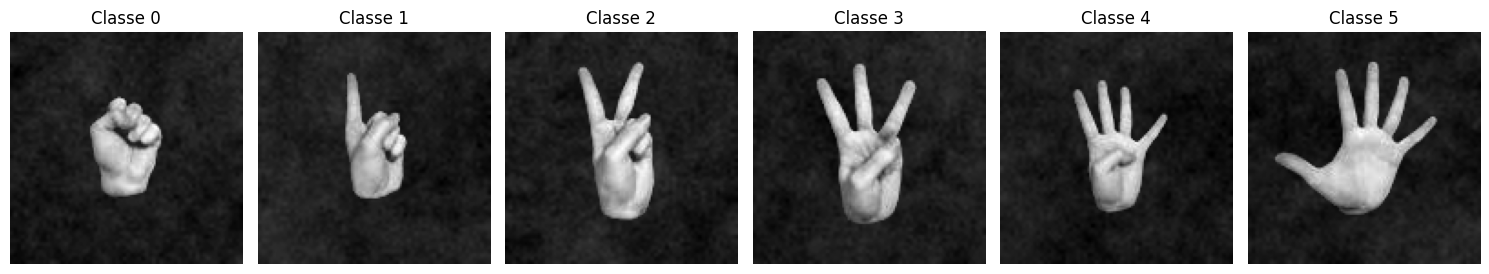

In [25]:
classes = np.unique(y_train)
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))

for i, cls in enumerate(classes):
    idx = np.where(y_train == cls)[0][0]
    axes[i].imshow(x_train[idx], cmap='gray')
    axes[i].set_title(f'Classe {cls}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Dataset de teste

In [26]:
# carregando as informações
data_img_teste = extract_class('fingers/test')

In [27]:
# carregando as cinco primeiras linahs
data_img_teste.head()

,nome_arquivo,dedos,mao,array_imagem
0,000e7aa6-100b-4c6b-9ff0-e7a8e53e4465_5L.png,5,L,"[[71, 70, 70, 71, 74, 74, 69, 68, 68, 67, 63, ..."
1,001f6021-8581-4ed2-aed4-cda0af1d5d57_5L.png,5,L,"[[42, 44, 50, 52, 49, 48, 48, 46, 43, 44, 50, ..."
2,0027029b-4c3c-4785-bc1b-b8141331a108_3R.png,3,R,"[[41, 39, 36, 36, 38, 41, 43, 45, 47, 49, 52, ..."
3,004599fb-c735-4ff3-a969-342dda319382_5L.png,5,L,"[[59, 58, 58, 57, 57, 58, 61, 63, 65, 66, 65, ..."
4,00500e1a-f4bd-4f66-9eb8-c7fce19a3f6f_5L.png,5,L,"[[55, 56, 59, 59, 57, 58, 62, 65, 64, 63, 61, ..."


In [28]:
# carregando as cinco últimas linhas
data_img_teste.tail()

,nome_arquivo,dedos,mao,array_imagem
3595,ff78cf4f-d03c-4b41-9dbc-03bdfdf241bf_2R.png,2,R,"[[62, 64, 67, 67, 65, 62, 58, 55, 52, 52, 54, ..."
3596,ff8be861-dd82-4500-893f-e9b6e299c5e1_0L.png,0,L,"[[61, 60, 57, 55, 53, 54, 59, 59, 54, 51, 49, ..."
3597,ff9eeef5-2c62-4bce-9d29-587345a7acfe_4R.png,4,R,"[[28, 28, 28, 28, 28, 32, 40, 42, 38, 38, 42, ..."
3598,ffb7e43c-deac-4b8f-83bf-44437104c35d_3R.png,3,R,"[[40, 40, 39, 35, 31, 34, 44, 48, 47, 46, 44, ..."
3599,ffb81e76-93e8-4e7f-87cf-7a91a62c8f25_3R.png,3,R,"[[68, 66, 62, 61, 64, 68, 72, 73, 70, 70, 72, ..."


In [29]:
# verificando a quantidade de linhas e colunas do dataframe
print('quantidade de linhas  --> ', data_img_teste.shape[0])
print('quantidade de colunas --> ', data_img_teste.shape[1])

quantidade de linhas  -->  3600
quantidade de colunas -->  4


In [30]:
# tipo das variáveis 
data_img_teste.dtypes

nome_arquivo    object
dedos            int64
mao             object
array_imagem    object
dtype: object

In [31]:
# Verificação de na's
data_img_teste.isna().sum()

nome_arquivo    0
dedos           0
mao             0
array_imagem    0
dtype: int64

### Verificação do balanceamento

In [32]:
# Classes igualmente balanceadas
data_img_teste['dedos'].value_counts()

dedos
5    600
3    600
4    600
2    600
1    600
0    600
Name: count, dtype: int64

In [33]:
# Distribuição da quantidade de dedos com a mão esquerda --> 50%
data_img_teste['dedos'].loc[data_img_teste['mao']=='L'].value_counts()

dedos
5    300
1    300
0    300
4    300
2    300
3    300
Name: count, dtype: int64

In [34]:
# Distribuição da quantidade de dedos com a mão direita --> 50% --> 16.67% para cada classe
data_img_teste['dedos'].loc[data_img_teste['mao']=='R'].value_counts(normalize=True)

dedos
3    0.166667
4    0.166667
2    0.166667
5    0.166667
1    0.166667
0    0.166667
Name: proportion, dtype: float64

### Criando os arrays de x_test e y_test

In [35]:
# Criando o array dos dados de treino
x_test = data_img_teste['array_imagem'].copy()
x_test.shape

(3600,)

In [36]:
# array de uma dimensao
x_test.ndim

1

In [37]:
x_test[0]

array([[71, 70, 70, ..., 53, 54, 55],
       [70, 71, 71, ..., 51, 53, 54],
       [70, 71, 73, ..., 47, 49, 50],
       ...,
       [45, 43, 41, ..., 65, 66, 67],
       [47, 44, 39, ..., 62, 65, 66],
       [48, 45, 37, ..., 61, 64, 65]], dtype=uint8)

In [38]:
# transformando o array 
x_test = np.array(x_test.tolist())

In [39]:
x_test.shape

(3600, 128, 128)

In [40]:
# Redimensionar para incluir o canal de cor (1 canal, pois é grayscale)
x_test = x_test.reshape(-1, 128, 128, 1)

In [41]:
x_test.shape

(3600, 128, 128, 1)

In [42]:
# y_test --> rotulos das classes 
y_test = data_img_teste['dedos'].copy()

In [43]:
y_test = np.array(y_test.tolist())

In [44]:
y_test.shape

(3600,)

In [45]:
# quantidade de classes unicas dos rótulos
classes = np.unique(y_test)
classes

array([0, 1, 2, 3, 4, 5])

### Confirme que os rótulos correspondem às imagens

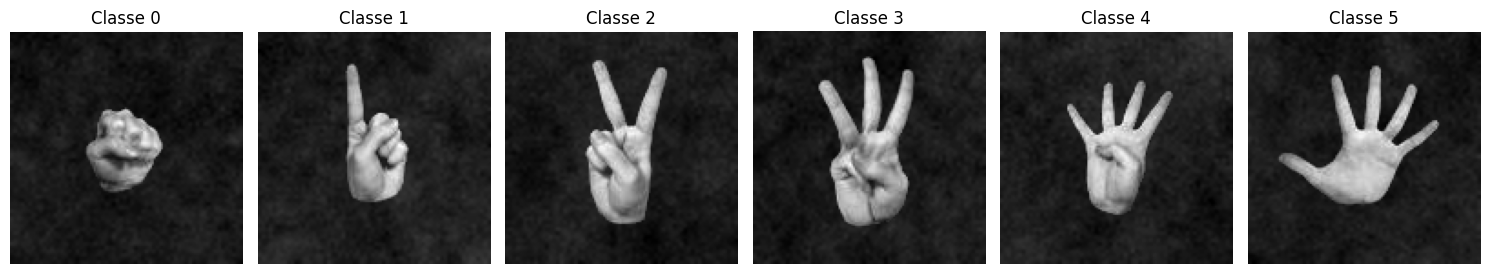

In [46]:
classes = np.unique(y_test)
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))

for i, cls in enumerate(classes):
    idx = np.where(y_test == cls)[0][0]
    axes[i].imshow(x_test[idx], cmap='gray')
    axes[i].set_title(f'Classe {cls}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Converter labels para one-hot encoding

In [47]:
y_train = tf.keras.utils.to_categorical(y_train, 6)
y_test  = tf.keras.utils.to_categorical(y_test,  6)

# 3. Data Augmentation e Geradores de Imagens

## Definindo os diferentes parâmetros de Data Augmentation

### Dados de treino

In [48]:
# Configure o ImageDataGenerator para treino com augmentation
train_datagen = ImageDataGenerator(
    rescale= 1.0/255,                   # Reescalar os pixels para o intervalo [0, 1]
    validation_split = 0.2,             # Separa 20% dos dados para validação
    rotation_range = 15,                # Rotação aleatória até 10 graus
    width_shift_range  = 0.15,         # Deslocamento vertical
    height_shift_range = 0.15,         # Deslocamento horizontal
    zoom_range = 0.05,                  # Zoom aleatório
    shear_range = 0.05,                  # cisalhamento
    brightness_range = [0.9, 1.1],      # Brilho
    fill_mode = 'nearest'               # Preenchendo pixels
)

In [49]:
# GENERATOR DE VALIDAÇÃO

validation_datagen = ImageDataGenerator(

    rescale = 1.0 / 255,

    validation_split = 0.2
)


In [50]:
# TRAIN GENERATOR
# =====================================================

train_generator = train_datagen.flow(

    x_train,

    y_train,

    batch_size = BATCH_SIZE,

    subset = 'training',

    shuffle = True,

    seed = 42
)

In [51]:
# VALIDATION GENERATOR
# =====================================================

validation_generator = validation_datagen.flow(

    x_train,

    y_train,

    batch_size = BATCH_SIZE,

    subset = 'validation',

    shuffle = False,

    seed = 42
)

In [52]:
print('Quantidade de dados de treinamento:', train_generator.n)

print('Quantidade de dados de validação:', validation_generator.n)

Quantidade de dados de treinamento: 14400
Quantidade de dados de validação: 3600


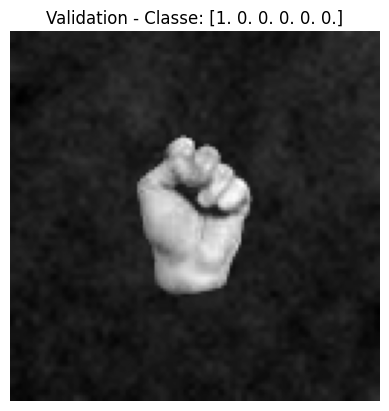

In [53]:
images_val, labels_val = next(validation_generator)

plt.imshow(
    images_val[0].squeeze(),
    cmap='gray'
)

plt.title(f"Validation - Classe: {labels_val[0]}")

plt.axis('off')

plt.show()

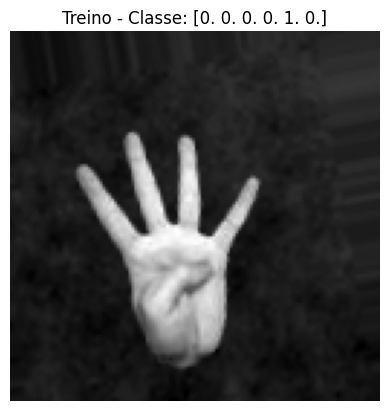

In [54]:
images_train, labels_train = next(train_generator)

plt.imshow(
    images_train[24].squeeze(),
    cmap='gray'
)

plt.title("Treino")
plt.title(f"Treino - Classe: {labels_train[24]}")

plt.axis('off')

plt.show()

### Dados de teste

In [55]:
# Configure o ImageDataGenerator para treino com augmentation
test_datagen = ImageDataGenerator(
    rescale= 1.0/255,                   # Reescalar os pixels para o intervalo [0, 1]
)

In [56]:
test_generator = test_datagen.flow(
    x_test,
    y_test,
    batch_size  = BATCH_SIZE,
    shuffle = False
)

# 4. Visualização e Análise Exploratória

Shape do batch de imagens:
(32, 128, 128, 1)

Shape dos labels:
(32, 6)

Range dos pixels:
0.054901965 0.9843138


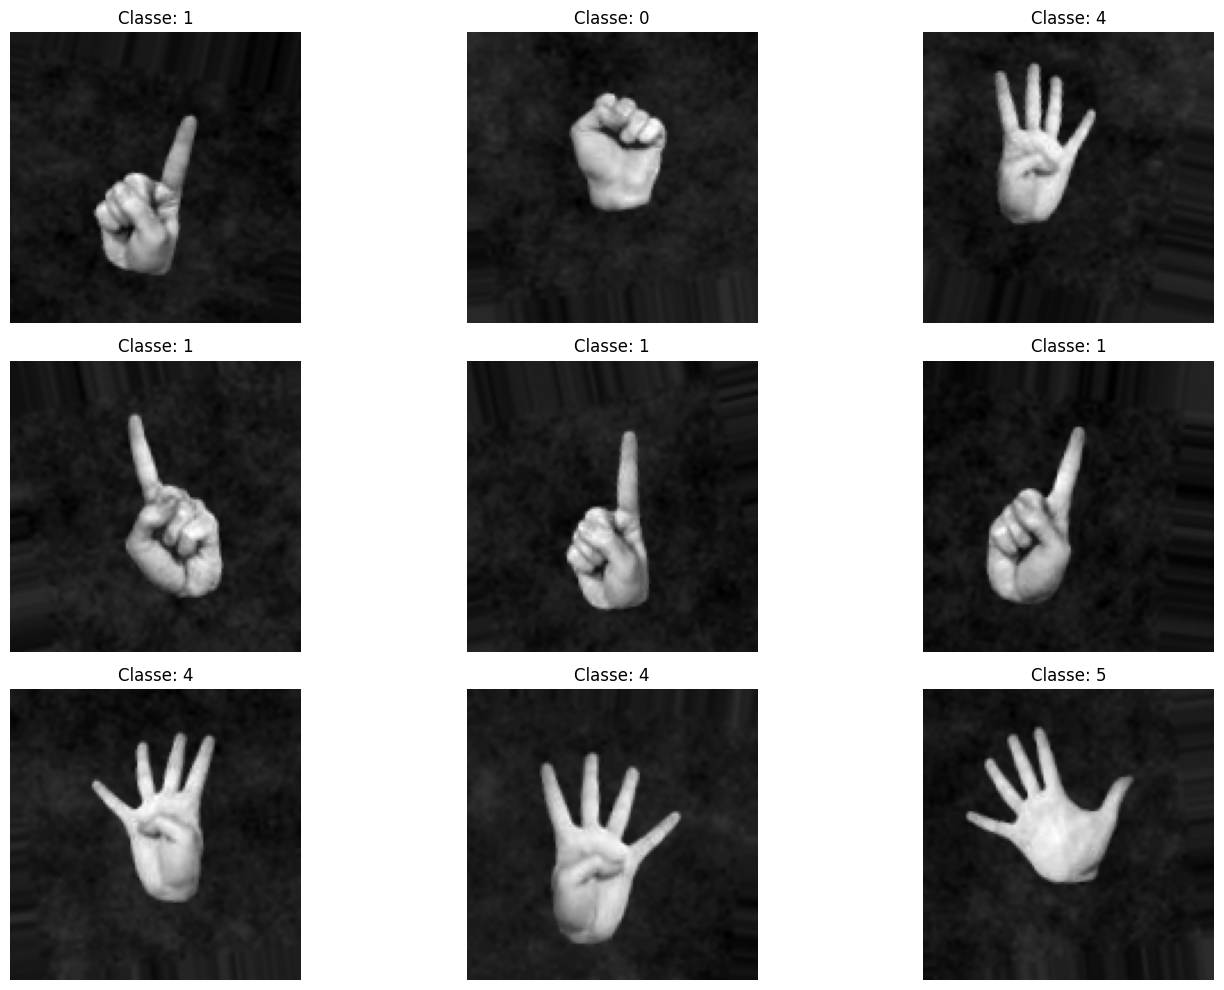

In [57]:
# Obtenha um batch de imagens do gerador de treino
images, labels = next(train_generator)

# Informações
print("Shape do batch de imagens:")
print(images.shape)

print("\nShape dos labels:")
print(labels.shape)

print("\nRange dos pixels:")
print(images.min(), images.max())


# VISUALIZAÇÃO das imagens

plt.figure(figsize=(15, 10))

for i in range(min(9, len(images))):

    plt.subplot(3, 3, i + 1)
    # REMOVE DIMENSÃO DO CANAL
    img = images[i].squeeze()

    # VISUALIZAÇÃO
    plt.imshow(
        img,
        cmap='gray'
    )

    # CONVERSÃO ONE-HOT -> CLASSE
    class_label = np.argmax(labels[i])
    plt.title(
        f"Classe: {class_label}"
    )
    plt.axis('off')
plt.tight_layout()
plt.show()

Shape do batch de imagens:
(32, 128, 128, 1)

Shape dos labels:
(32, 6)

Range dos pixels:
0.043137256 0.9803922


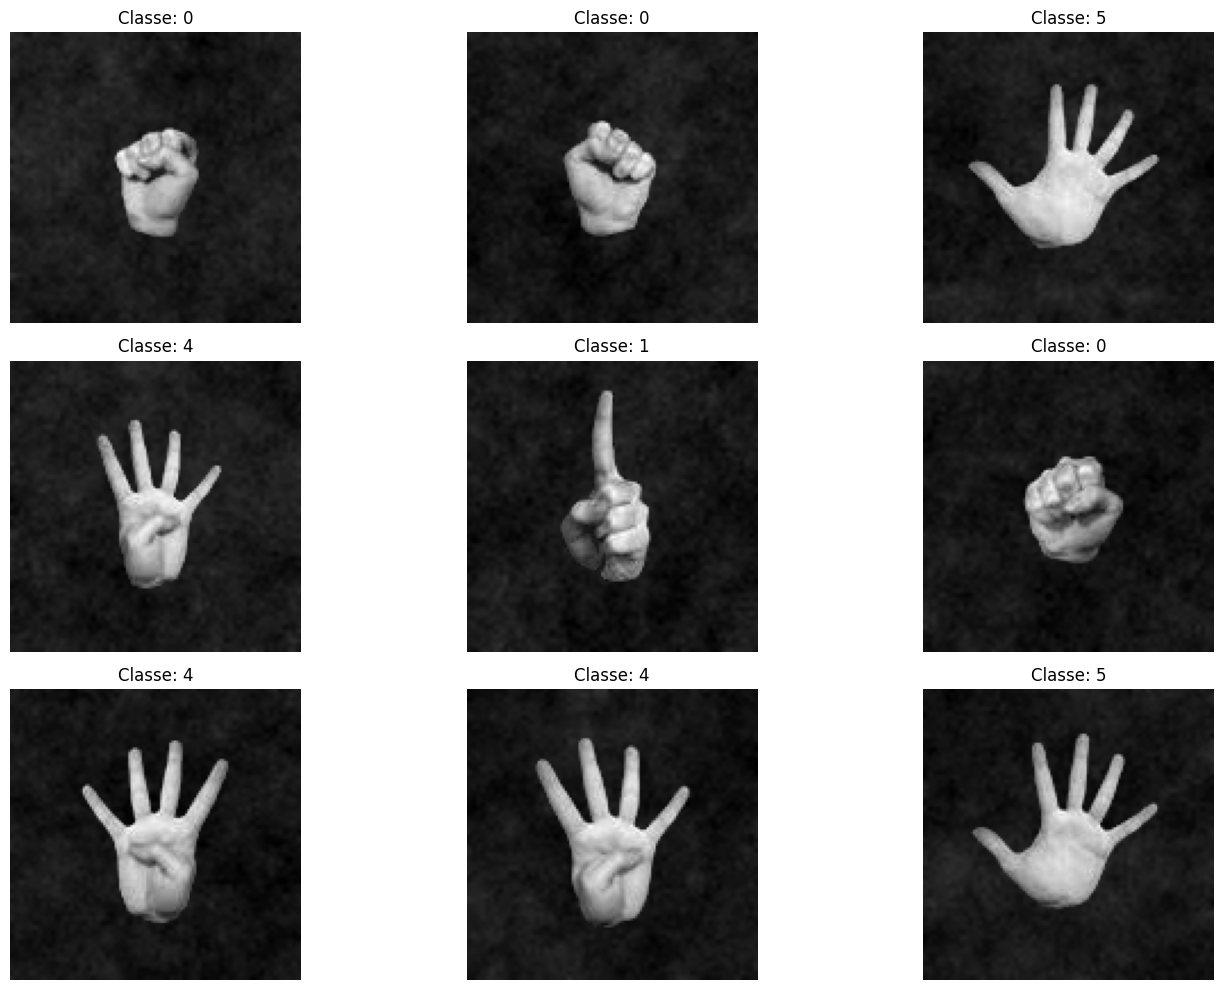

In [58]:
# Obtenha um batch de imagens do gerador de validacao
images, labels = next(validation_generator)

# Informações
print("Shape do batch de imagens:")
print(images.shape)

print("\nShape dos labels:")
print(labels.shape)

print("\nRange dos pixels:")
print(images.min(), images.max())


# VISUALIZAÇÃO das imagens

plt.figure(figsize=(15, 10))

for i in range(min(9, len(images))):

    plt.subplot(3, 3, i + 1)
    # REMOVE DIMENSÃO DO CANAL
    img = images[i].squeeze()

    # VISUALIZAÇÃO
    plt.imshow(
        img,
        cmap='gray'
    )

    # CONVERSÃO ONE-HOT -> CLASSE
    class_label = np.argmax(labels[i])
    plt.title(
        f"Classe: {class_label}"
    )
    plt.axis('off')
plt.tight_layout()
plt.show()

# 5. Construção da Arquitetura do Modelo

Arquitetura sequencial completa

**Camada de Input**:
   ```python
   layers.Input((128, 128, 3))
   ```

**Primeiro Bloco Convolucional:**

* Implemente uma camada Conv2D com:
    * 32 filtros
    * Kernel size 3x3
    * Ativação ReLU
* Adicione uma camada MaxPooling2D com pool size 2x2

**Segundo Bloco Convolucional:**

* Aumente para 64 filtros
* Mantenha as mesmas configurações do primeiro bloco

**Terceiro Bloco Convolucional:**

* Aumente para 128 filtros
* Mantenha as outras configurações

**Camadas Densas (Fully Connected):**

* Adicione uma camada Flatten() para transformar os features em 1D
* Implemente Dropout de 50% para regularização
* Adicione uma Dense layer com 128 neurônios e ativação ReLU
* Finalize com uma Dense layer de saída com ativação softmax

In [59]:
# Definir o modelo CNN
model = Sequential(name='Fingers_CNN')

# Camada de entrada
model.add(
    Input(shape=(128, 128, 1), name='input_layer')
)                   

In [60]:
# Primeira camada convolucional
model.add(
    Conv2D(
            filters=32,  # Número de filtros
            kernel_size=(3, 3),  # Tamanho do filtro
            activation='relu',  # Função de ativação
            name='conv1',  # Nome da camada
        )
)
# Primeira Camada de pooling
model.add(
    MaxPooling2D(
            pool_size=(2, 2),  # Tamanho do pooling
            name='pool1',  # Nome da camada
        )
)

In [61]:
# Segunda camada convolucional
model.add(
    Conv2D(
            filters=64,  # Número de filtros
            kernel_size=(3, 3),  # Tamanho do filtro
            activation='relu',  # Função de ativação
            name='conv2',  # Nome da camada
        )
)

# Segunda camada de pooling
model.add(
    MaxPooling2D(
            pool_size=(2, 2),  # Tamanho do pooling
            name='pool2',  # Nome da camada
        )
)

In [62]:
# Terceira camada convolucional
model.add(
    Conv2D(
            filters=128,  # Número de filtros
            kernel_size=(3, 3),  # Tamanho do filtro
            activation='relu',  # Função de ativação
            name='conv3',  # Nome da camada
        )
)

# terceira camada de pooling
model.add(
    MaxPooling2D(
            pool_size=(2, 2),  # Tamanho do pooling
            name='pool3',  # Nome da camada
        )
)

In [63]:
# Flattening
model.add(
    Flatten(name='flatten_1')  # Achata a saída para um vetor
)

# Camada dropout 
model.add(
    Dropout(
            0.5,
            name='dropout1',  # Nome da camada
        )
)

# Camada densa
model.add(
    Dense(
            units=128,  # Número de neurônios
            activation='relu',  # Função de ativação
            name='dense1',  # Nome da camada
        )
)
# Camada de saída
model.add(
    Dense(
            units=6,  # Número de classes
            activation='softmax',  # Função de ativação para classificação
            name='output_layer',  # Nome da camada
        )
)

In [64]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile( 
                optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy', 'recall', 'precision']
)

In [65]:
model.summary()

Model: "Fingers_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                       │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3 (Conv2D)                       │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling2D)                 │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout1 (Dropout)                   │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense1 (Dense)                       │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,838 (12.61 MB)

 Trainable params: 3,304,838 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# 6. Treinamento e Monitoramento

## Callbacks

In [66]:
# EarlyStopping: para evitar overfitting, interrompe o treino se a validação parar de melhorar
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

callback_list  = [ 
    callbacks.EarlyStopping(
                            monitor='val_loss',
                            patience=5,
                            restore_best_weights=True
                            ),
    callbacks.ReduceLROnPlateau(
                            monitor='val_loss',
                            patience=3,
                            factor=0.2,
                            min_lr=1e-6
                            ),
    callbacks.ModelCheckpoint(
                            "best_model_fingers.keras",
                            monitor='val_accuracy',
                            save_best_only=True,
                            mode='max',
                            verbose=1
                            ),
    callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
]
    


In [67]:
import time
tempo_1 = time.time()

In [68]:
history = model.fit(
    #x_train, y_train,
    train_generator,
    #batch_size=64,
    epochs=EPOCHS,
    #validation_data=(x_test, y_test),
    validation_data=validation_generator,
    callbacks = callback_list,
    verbose=1
)

Epoch 1/20


C:\Users\p0137852\projetos_tjmg\teste\venv_teste_2024\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.4047 - loss: 1.4135 - precision: 0.6157 - recall: 0.1585

C:\Users\p0137852\projetos_tjmg\teste\venv_teste_2024\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.92444, saving model to best_model_fingers.keras
450/450 ━━━━━━━━━━━━━━━━━━━━ 112s 244ms/step - accuracy: 0.4051 - loss: 1.4126 - precision: 0.6161 - recall: 0.1590 - val_accuracy: 0.9244 - val_loss: 0.3024 - val_precision: 0.9410 - val_recall: 0.8942 - learning_rate: 1.0000e-04
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.8249 - loss: 0.4704 - precision: 0.8654 - recall: 0.7750
Epoch 2: val_accuracy improved from 0.92444 to 0.95250, saving model to best_model_fingers.keras
450/450 ━━━━━━━━━━━━━━━━━━━━ 109s 241ms/step - accuracy: 0.8250 - loss: 0.4703 - precision: 0.8654 - recall: 0.7750 - val_accuracy: 0.9525 - val_loss: 0.1582 - val_precision: 0.9550 - val_recall: 0.9489 - learning_rate: 1.0000e-04
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9045 - loss: 0.2761 - precision: 0.9190 - recall: 0.8889
Epoch 3: val_accuracy improved from 0.95250 to 0.96556, saving model to best_model_fingers.keras

In [69]:
tempo_2 = time.time()
total = (tempo_2 - tempo_1) / 60
total

38.29194125334422

In [70]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])

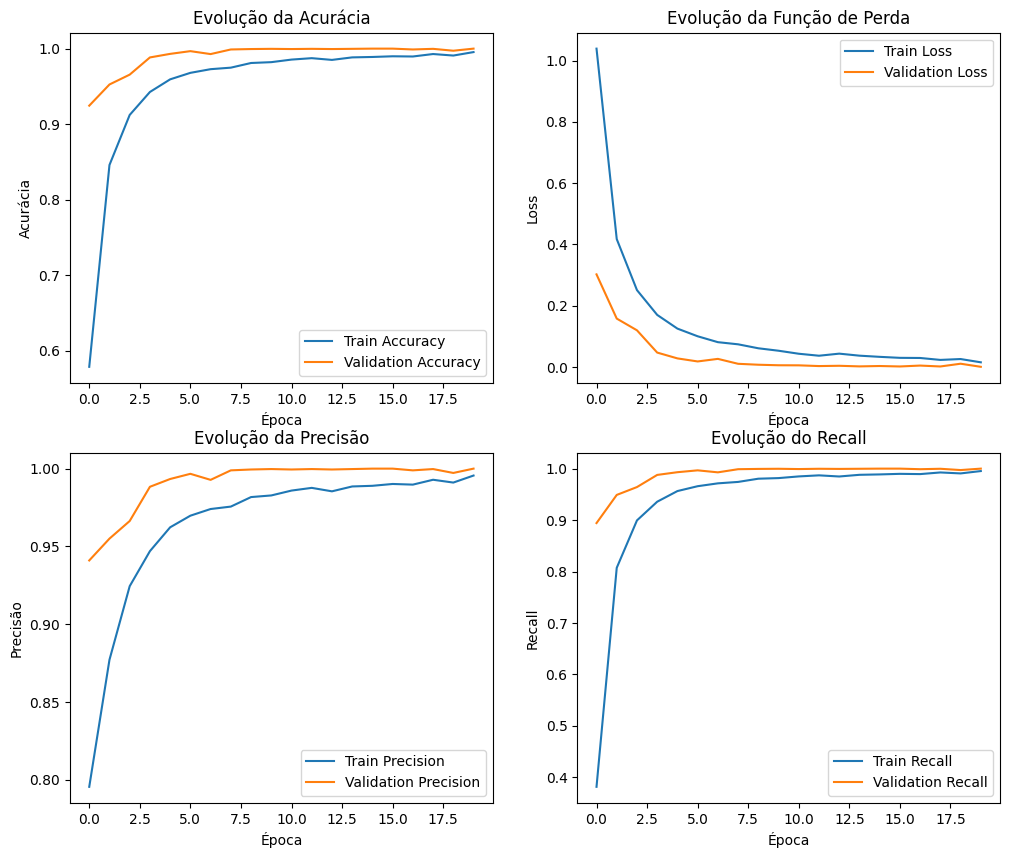

In [71]:
plt.figure(figsize=(12, 10))

# Gráfico de Acurácia
plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

# Gráfico de Perda
plt.subplot(2, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Evolução da Função de Perda')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

# Gráfico da Precisão
plt.subplot(2, 2, 3)
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Validation Precision')
plt.title('Evolução da Precisão')
plt.xlabel('Época')
plt.ylabel('Precisão')
plt.legend()

# Gráfico de Recall
plt.subplot(2, 2, 4)
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')
plt.title('Evolução do Recall')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.legend()

plt.show()

In [72]:
loss, acc, recall, precision = model.evaluate(validation_generator, verbose=False)
print(f"\nAcurácia final na validação: {acc:.4f}")
print(f"Recall final na validação: {recall:.4f}")
print(f"Precisão final na validação: {precision:.4f}")


Acurácia final na validação: 1.0000
Recall final na validação: 1.0000
Precisão final na validação: 1.0000


# 7. Avaliação e Análise de Resultados

In [73]:
# Predição no conjunto de teste
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step


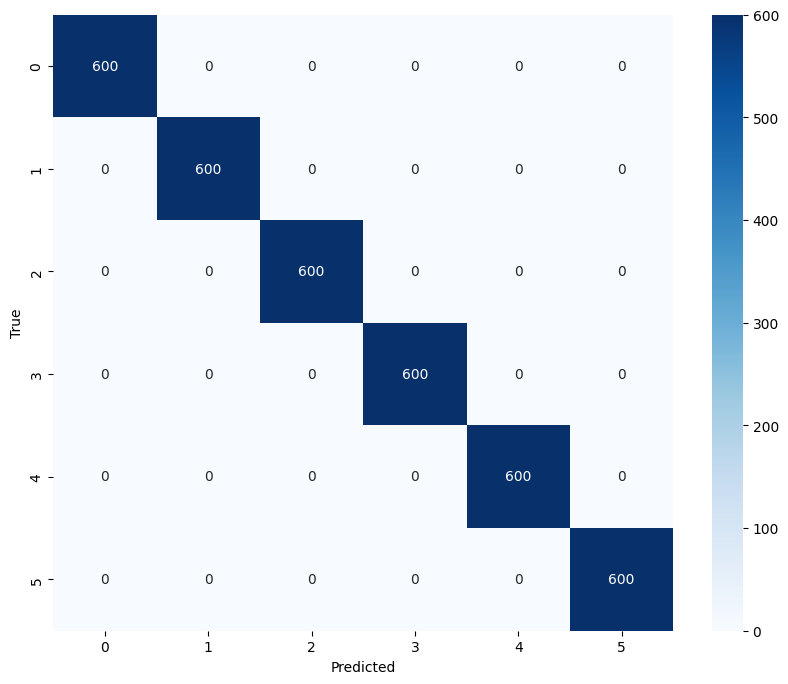

In [74]:
# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [75]:
# Relatório de Classificação
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       600
           1       1.00      1.00      1.00       600
           2       1.00      1.00      1.00       600
           3       1.00      1.00      1.00       600
           4       1.00      1.00      1.00       600
           5       1.00      1.00      1.00       600

    accuracy                           1.00      3600
   macro avg       1.00      1.00      1.00      3600
weighted avg       1.00      1.00      1.00      3600

